In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-shows/netflix_titles.csv


🎬 Netflix Global Content Analysis
---
**Author:** [Avishkar Pawar]  
**Date:** February 2026  
**Tools:** `Python` | `Pandas` | `Seaborn` | `Matplotlib`

In [2]:
import pandas as pd
df= pd.read_csv('/kaggle/input/netflix-shows/netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [3]:
df.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

# HADLING NULL VALUE

In [4]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:

df.fillna({'date_added': 'UnKnow'},inplace=True)
df.fillna({'duration': 'UnKnow'},inplace=True)
df.fillna({'country': 'UnKnow'},inplace=True)
df.isna().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country            0
date_added         0
release_year       0
rating             4
duration           0
listed_in          0
description        0
dtype: int64

In [6]:
df.fillna({'rating': 'UnKnow'},inplace=True)
df.fillna({'director':'UnKnow'},inplace=True)
df.fillna({'cast':'unknow'},inplace=True)
df.isna().sum()


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [7]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

#  Netflix content strategy Analysis
Tools : Python | Pandas | Seaborn | Matplotlib

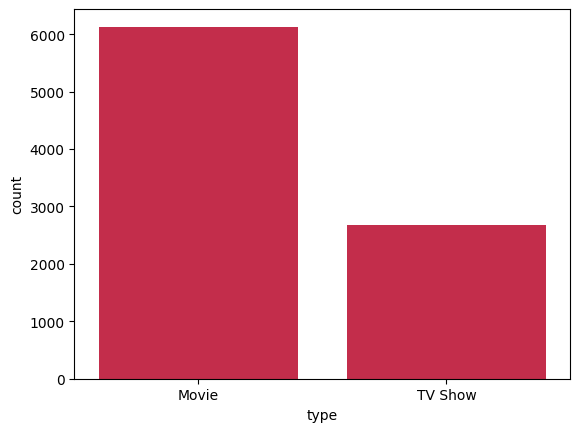

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
var = df['type']
sns.countplot(x = var,color='crimson')
plt.show()


# # In type count of  movies is higher than a TV shows.

In [9]:
year=df['release_year'].value_counts().sort_index()
year.tail(20)

release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

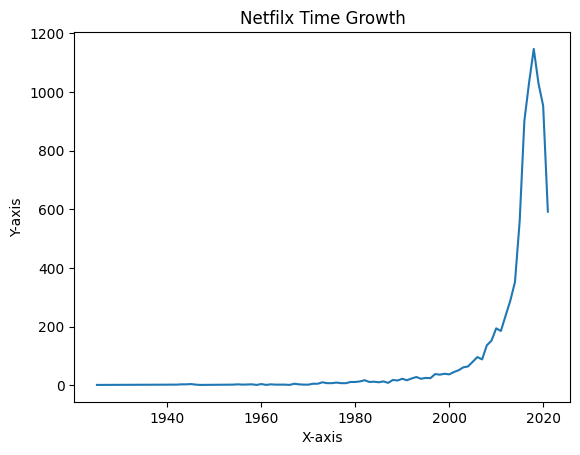

In [10]:
year.plot()
plt.title("Netfilx Time Growth")
plt.ylabel('Y-axis')
plt.xlabel('X-axis')
plt.show()

# Between 2017 and 2019 , the data reveals massive surge in content additions.

In [11]:
top_country=df['country'].value_counts().head(10)
top_country

country
United States     2818
India              972
UnKnow             831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

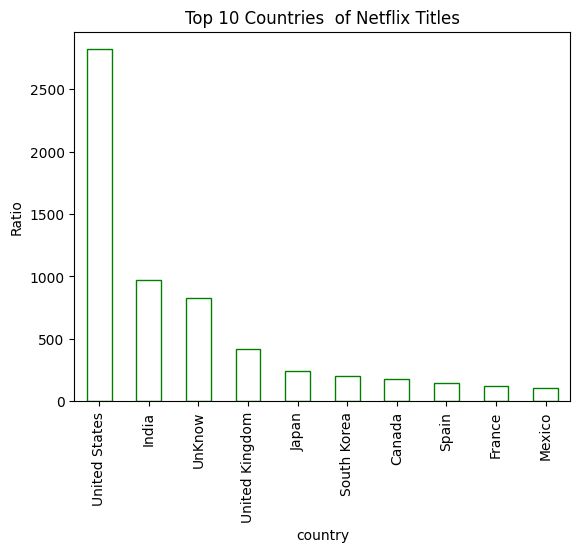

In [12]:
top_country.plot(kind='bar',color='w',edgecolor='green')
plt.ylabel("Ratio")
plt.title('Top 10 Countries  of Netflix Titles')
plt.show()

# The United States is consistently at the 1st , India typically holds 2nd spot

In [13]:
ratings = df['rating'].value_counts()
ratings.head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

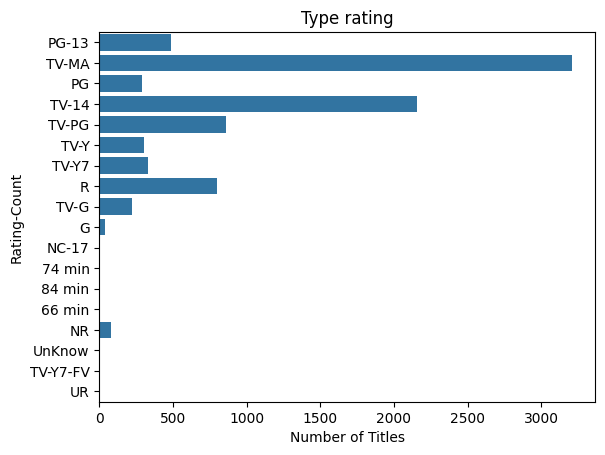

In [14]:

sns.countplot(y=df['rating'])
plt.ylabel("Rating-Count")
plt.xlabel("Number of Titles")
plt.title("Type rating")
plt.show()

# TV-MA has a largest rating and than TV-14 often the second largest.

In [15]:
geners=df['listed_in'].str.split(',').explode().value_counts().head(10)
geners

listed_in
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64

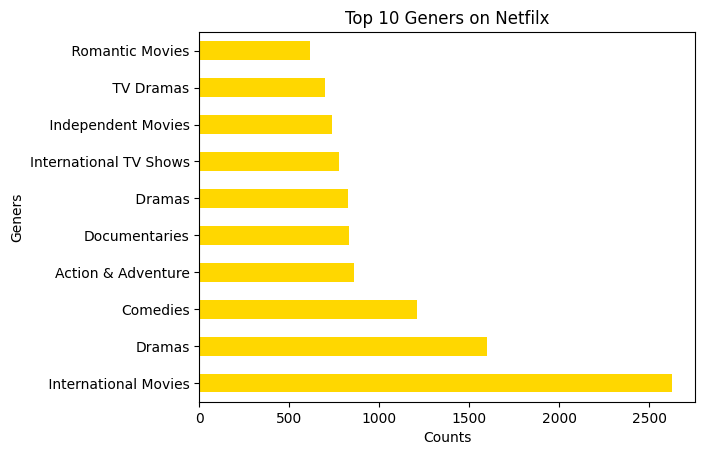

In [16]:
geners.plot(kind='barh',color='gold')
plt.title("Top 10 Geners on Netfilx")
plt.xlabel("Counts")
plt.ylabel('Geners')
plt.show()

# International Movies,Dramas,Comedies take the top spots.

<h1> >Netflix Strategy Insights</h1>
<h1>.The 2017-2019 Boom: content surged exponentially as netflix</h1>
<h1>.The Adult Audience Focus:TV-MA is the most frequent rating,showing a clear focus on adult drams over family content</h1>
<h1>.Global Diversification: Outside of the US,India is the leading content contributer,driven by a massive library of international Dramas</h1>
